# **RUN THE COMMAND 2 TIMES**

In [1]:
!pip install mediapipe opencv-python tensorflow

# **BASIC MODULES**

In [2]:
import pandas as pd
import numpy as np
import os
import logging

# **KEY ML & DL IMPORTS**

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout,
    LSTM, TimeDistributed, Bidirectional,
    Conv1D, MaxPooling1D, SeparableConv1D, SeparableConv2D,
    Activation, Masking, Input, LayerNormalization
)
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, RMSprop

# **Mount Google Drive**

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_PATH = "/content/drive/MyDrive/Merged"

In [6]:
np.random.seed(42)
tf.random.set_seed(42)
MAX_SEQUENCE_LENGTH = 75
NUM_FEATURES = 195
BATCH_SIZE = 32
EPOCHS = 100
CLASSES = ['Afternoon', 'Apple', 'April', 'August', 'Banana', 'Day', 'December', 'Evening',
           'Febraury', 'Friday', 'Grapes', 'January', 'July', 'June', 'March', 'May', 'Monday',
           'Morning', 'Night', 'November', 'October', 'Orange', 'Rainy', 'Saturday', 'September',
           'Summer', 'Sunday', 'Thursday', 'Tuesday', 'Valencia_Orange', 'Watermelon', 'Wednesday', 'Winter']

NUM = len(CLASSES)

print(NUM)
print(NUM_FEATURES)

33
195


# **Data Transformation and Normalization**




In [7]:
# prompt: load X and y from the drive (npy )

X = np.load('/content/drive/MyDrive/Frames/X_195_75.npy')
y = np.load('/content/drive/MyDrive/Frames/y_195_75.npy')
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2319, 75, 195)
y shape: (2319,)


In [8]:
from sklearn.preprocessing import StandardScaler

# Reshape X to be 2D for StandardScaler
X_reshaped = X.reshape(-1, X.shape[-1])

# Initialize and fit the StandardScaler
scaler = StandardScaler()
scaler.fit(X_reshaped)

# Transform the data and reshape back to the original 3D shape
X_normalized = scaler.transform(X_reshaped)
X = X_normalized.reshape(X.shape)

print("X data normalized.")
print("X shape:", X.shape)
print("y shape:", y.shape)

X data normalized.
X shape: (2319, 75, 195)
y shape: (2319,)


#**Train, Test and Validation split**

In [9]:
# prompt: train test and validate the data in the ratio = 7:2:1

# Calculate the sizes for train, validation, and test sets
train_size = 0.7
val_size = 0.1
test_size = 0.2

# Split the data into training and remaining (validation + test)
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=train_size, random_state=42, stratify=y)

# Calculate the ratio of validation and test sets from the remaining data
# val_size_rem = val_size / (val_size + test_size)
# test_size_rem = test_size / (val_size + test_size) # This is 1 - val_size_rem

# Split the remaining data into validation and test sets
# Since we want a 7:2:1 split of the *original* data, the ratio of val:test
# within the remaining data (y_rem) is val_size / (val_size + test_size)
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=(test_size/(val_size + test_size)), random_state=42, stratify=y_rem)


print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, num_classes=NUM)
y_val_cat = to_categorical(y_val, num_classes=NUM)
y_test_cat = to_categorical(y_test, num_classes=NUM)

print(f"Shape of y_train_cat: {y_train_cat.shape}")
print(f"Shape of y_val_cat: {y_val_cat.shape}")
print(f"Shape of y_test_cat: {y_test_cat.shape}")

Shape of X_train: (1623, 75, 195)
Shape of y_train: (1623,)
Shape of X_val: (232, 75, 195)
Shape of y_val: (232,)
Shape of X_test: (464, 75, 195)
Shape of y_test: (464,)
Shape of y_train_cat: (1623, 33)
Shape of y_val_cat: (232, 33)
Shape of y_test_cat: (464, 33)


# **CUSTOM Transformer Model**

In [11]:
import tensorflow.keras as keras
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import regularizers

# Positional Encoding Layer
@keras.utils.register_keras_serializable(package="custom")
class PositionalEncodingLayer(layers.Layer):
    def __init__(self, seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.seq_len  = seq_len
        self.d_model  = d_model
        self.pos_encoding = self._positional_encoding(seq_len, d_model)

    # Keras serialization
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"seq_len": self.seq_len, "d_model": self.d_model})
        return cfg

    @classmethod
    def from_config(cls, config):
        return cls(**config)


    def _positional_encoding(self, seq_len, d_model):
        pos   = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
        i     = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
        angle = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle = pos * angle
        sines = tf.sin(angle[:, 0::2])
        coses = tf.cos(angle[:, 1::2])
        encoding = tf.concat([sines, coses], axis=-1)
        return encoding[tf.newaxis, ...]

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

#Transformer Encoder Block
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size,
                                  dropout=dropout)(x, x)
    x = layers.Dropout(dropout)(x)
    x = layers.Add()([inputs, x])              # residual

    y = layers.LayerNormalization(epsilon=1e-6)(x)
    y = layers.Dense(ff_dim, activation="gelu",
                     kernel_regularizer=regularizers.l2(1e-4))(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Dense(inputs.shape[-1])(y)
    y = layers.Dropout(dropout)(y)
    return layers.Add()([x, y])                # residual

# Model Builder
def build_transformer_model(input_shape, num_classes):
    inp = layers.Input(shape=input_shape)
    x   = PositionalEncodingLayer(input_shape[0], input_shape[1])(inp)

    for _ in range(4):
        x = transformer_encoder(x, head_size=64, num_heads=4,
                                ff_dim=128, dropout=0.3)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inp, out)

print("✅ PositionalEncodingLayer is now fully registered and serializable.")

✅ PositionalEncodingLayer is now fully registered and serializable.


In [13]:
# Build and compile the model
input_shape = (MAX_SEQUENCE_LENGTH, NUM_FEATURES)
transformer_model = build_transformer_model(input_shape, NUM)

optimizer = Adam(learning_rate=0.0005)
transformer_model.compile(optimizer=optimizer,
                          loss='categorical_crossentropy',
                          metrics=['accuracy'])

transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 195)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 75, 195)   │          0 │ input_layer[0][0] │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 75, 195)   │        390 │ positional_encod… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 75, 195)   │    200,643 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 75, 195)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 75, 195)   │          0 │ positional_encod… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 195)   │        390 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 75, 128)   │     25,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 75, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 75, 195)   │     25,155 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 75, 195)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 75, 195)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 195)   │        390 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 75, 195)   │    200,643 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 75, 195)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 75, 195)   │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 75, 195)   │        390 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 75, 128)   │     25,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 75, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,036,521 (3.95 MB)

 Trainable params: 1,036,265 (3.95 MB)

 Non-trainable params: 256 (1.00 KB)

In [14]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)
callbacks_list = [early_stopping, reduce_lr]


history = transformer_model.fit(
    X_train,
    y_train_cat, # Use one-hot encoded training labels
    epochs=200,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val_cat), # Use one-hot encoded validation labels
    callbacks=callbacks_list
)

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 48s 397ms/step - accuracy: 0.1115 - loss: 3.7085 - val_accuracy: 0.2672 - val_loss: 3.0041 - learning_rate: 5.0000e-04
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3689 - loss: 2.2223 - val_accuracy: 0.4655 - val_loss: 2.0431 - learning_rate: 5.0000e-04
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5585 - loss: 1.5739 - val_accuracy: 0.7457 - val_loss: 1.0341 - learning_rate: 5.0000e-04
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7234 - loss: 1.0830 - val_accuracy: 0.8060 - val_loss: 0.7946 - learning_rate: 5.0000e-04
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8044 - loss: 0.8505 - val_accuracy: 0.8147 - val_loss: 0.7550 - learning_rate: 5.0000e-04
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8275 - loss: 0.7218 - val_accuracy: 0.8276 - val_loss: 0.7379 - learning_rate: 5.0000e-04
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy

In [15]:
transformer_model.save('/content/drive/MyDrive/Transformer_final.keras')
print("Model saved successfully in keras format.")

Model saved successfully in keras format.


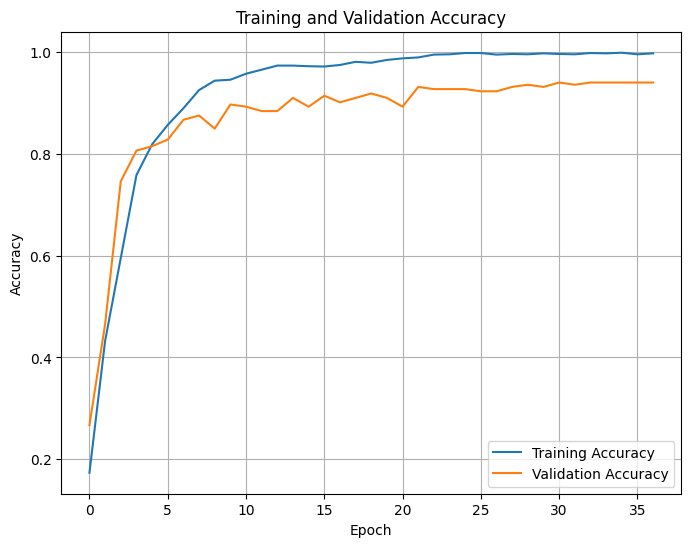

In [16]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
from sklearn.metrics import classification_report, accuracy_score

# Evaluate the model on the test set
loss, accuracy = transformer_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

# Generate predictions for the test set
y_pred = transformer_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

# Generate and print the classification report
report = classification_report(y_true_classes, y_pred_classes, target_names=CLASSES, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES))

# Print macro, micro, and weighted average metrics
print("\nAverages:")
print("  Macro Average:")
print(f"    Precision: {report['macro avg']['precision']:.4f}")
print(f"    Recall: {report['macro avg']['recall']:.4f}")
print(f"    F1-score: {report['macro avg']['f1-score']:.4f}")
print(f"    Support: {report['macro avg']['support']}")

print("\n  Micro Average:")
print(f"    Precision: {report['accuracy']:.4f}") # Micro average precision is accuracy
print(f"    Recall: {report['accuracy']:.4f}")    # Micro average recall is accuracy
print(f"    F1-score: {report['accuracy']:.4f}")    # Micro average f1-score is accuracy
print(f"    Support: {report['accuracy'] * report['macro avg']['support']:.0f}") # Total number of samples

print("\n  Weighted Average:")
print(f"    Precision: {report['weighted avg']['precision']:.4f}")
print(f"    Recall: {report['weighted avg']['recall']:.4f}")
print(f"    F1-score: {report['weighted avg']['f1-score']:.4f}")
print(f"    Support: {report['weighted avg']['support']}")

Test Accuracy: 0.9418
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step

Classification Report:
                 precision    recall  f1-score   support

      Afternoon       1.00      1.00      1.00        12
          Apple       1.00      0.92      0.96        13
          April       0.92      0.86      0.89        14
         August       1.00      1.00      1.00        13
         Banana       0.93      1.00      0.96        13
            Day       1.00      1.00      1.00        13
       December       0.94      1.00      0.97        15
        Evening       0.92      0.92      0.92        13
       Febraury       0.92      0.86      0.89        14
         Friday       0.93      1.00      0.97        14
         Grapes       0.88      1.00      0.94        15
        January       0.93      1.00      0.97        14
           July       1.00      1.00      1.00        15
           June       1.00      0.71      0.83        14
          March       1.00      1.00      1.00        14


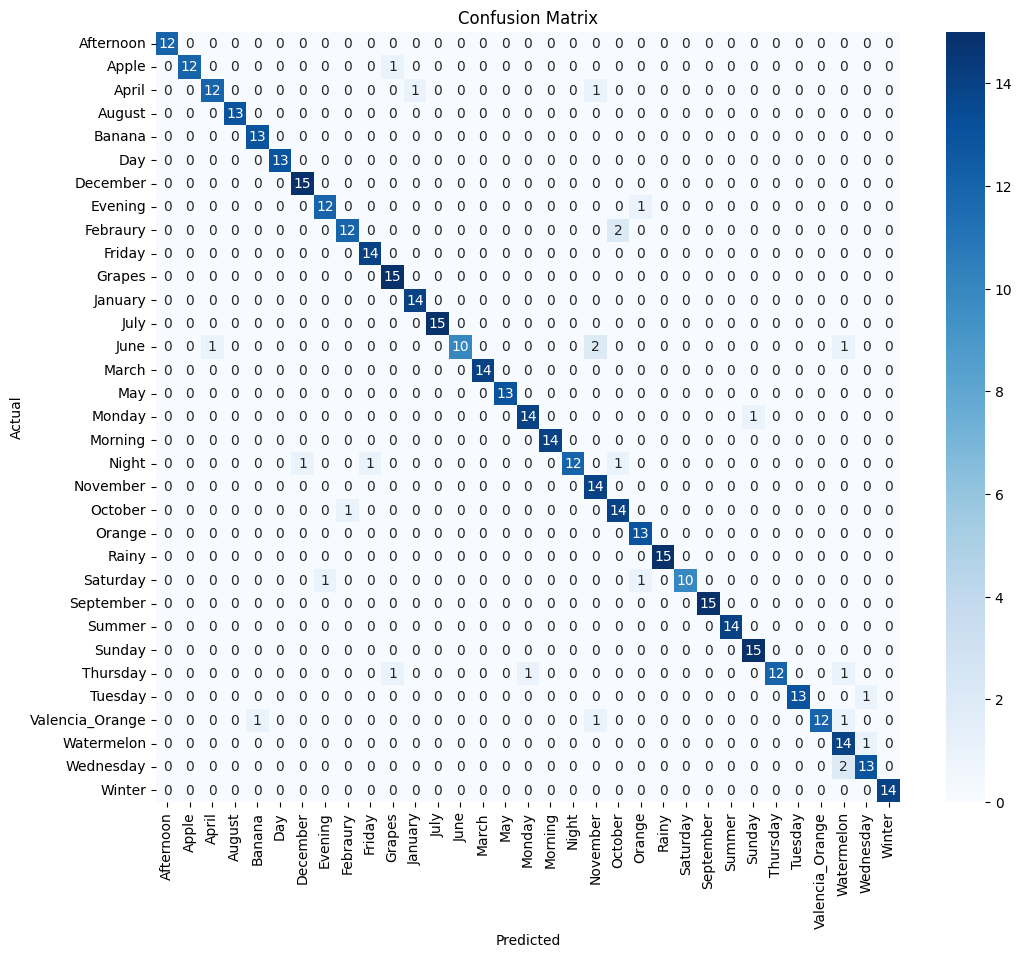

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()